In [1]:
import universe
# reload(universe)
from universe import *

import halo_fit
# reload(halo_fit)
from halo_fit import *

import weight
# reload(weight)
from weight import *

import pn_2d
# reload(pn_2d)
from pn_2d import *

import cmb
# reload(cmb)
from cmb import *

import flat_map
# reload(flat_map)
from flat_map import *

In [2]:
class StageIVCMB(CMB):
   
   def __init__(self, beam=1., noise=1., lMin=30., lMaxT=3.e3, lMaxP=5.e3, atm=False, name=None):
      # name
      #      self.name = "cmbs4"
      self.name = "cmbs4_beam"+str(round(beam, 3))+"_noise"+str(round(noise, 3))+"_lmin"+str(int(lMin))+"_lmaxT"+str(int(lMaxT))+"_lmaxP"+str(int(lMaxP))
      if atm:
         self.name += "_atmnoise"
      if name is not None:
         self.name += "_"+name

      # frequencies in Hz (irrelevant)
      self.nu1 = 143.e9
      self.nu2 = 143.e9
      # beam fwhm in radians (1 arcmin)
      self.fwhm = beam * (np.pi/180.)/60.
      # detector sensitivity in muK*rad.
      # 1 muK*arcmin
      self.sensitivity = noise * (np.pi/180.)/60.
      # ell limits
      self.lMin = lMin
      self.lMaxT = lMaxT
      self.lMaxP = lMaxP
      
      super(StageIVCMB, self).__init__()
      
      # add atmospheric noise if needed
      if atm:
         self.ftotalTT = lambda l: self.flensedTT(l) + self.fdetectorNoise(l) + self.fatmosphericNoiseTT(l)
         self.ftotalEE = lambda l: self.flensedEE(l) + 2.*self.fdetectorNoise(l) + self.fatmosphericNoisePP(l)
         self.ftotalBB = lambda l: self.flensedBB(l) + 2.*self.fdetectorNoise(l) + self.fatmosphericNoisePP(l)
         self.ftotalTE = lambda l: self.flensedTE(l)

In [3]:
# print "Map properties"

# number of pixels for the flat map
nX = 400 #1200
nY = 400 #1200

# map dimensions in degrees
sizeX = 10.
sizeY = 10.

# basic map object
baseMap = FlatMap(nX=nX, nY=nY, sizeX=sizeX*np.pi/180., sizeY=sizeY*np.pi/180.)

# multipoles to include in the lensing reconstruction
lMin = 30.; lMax = 3.5e3

# ell bins for power spectra
nBins = 21  # number of bins
lRange = (1., 2.*lMax)  # range for power spectra

cmb = StageIVCMB(beam=1., noise=1., lMin=lMin, lMaxT=lMax, lMaxP=lMax, atm=False)


self.l has shape [[   0.           36.           72.         ... 7128.
  7164.         7200.        ]
 [  36.           50.91168825   80.49844719 ... 7128.09090851
  7164.09045169 7200.08999944]
 [  72.           80.49844719  101.82337649 ... 7128.36362709
  7164.36179991 7200.359991  ]
 ...
 [ 108.          113.84199577  129.79984592 ... 7128.81813487
  7164.8140241  7200.80995444]
 [  72.           80.49844719  101.82337649 ... 7128.36362709
  7164.36179991 7200.359991  ]
 [  36.           50.91168825   80.49844719 ... 7128.09090851
  7164.09045169 7200.08999944]]


/Users/richardfeder/Documents/ciber/FlatSkyQE/basic_functions.py:98: RuntimeWarning: divide by zero encountered in divide
  try: return x/y
/Users/richardfeder/Documents/ciber/FlatSkyQE/cmb.py:127: RuntimeWarning: invalid value encountered in multiply
  data[:,1] *= self.fdl_to_cl(data[:,0]) # convert Dl to Cl
/Users/richardfeder/Documents/ciber/FlatSkyQE/cmb.py:135: RuntimeWarning: invalid value encountered in multiply
  data[:,1] *= self.fdl_to_cl(data[:,0]) # convert Dl to Cl
/Users/richardfeder/Documents/ciber/FlatSkyQE/cmb.py:149: RuntimeWarning: invalid value encountered in multiply
  data[:,1] *= self.fdl_to_cl(data[:,0]) # convert Dl to Cl


In [4]:
# print "CMB experiment properties"

# Adjust the lMin and lMax to the assumptions of the analysis
# CMB S3 specs
# cmb = StageIVCMB(beam=1., noise=1., lMin=lMin, lMaxT=lMax, lMaxP=lMax, atm=False)

# Total power spectrum, for the lens reconstruction
forCtotal = lambda l: cmb.flensedTT(l) + cmb.fdetectorNoise(l)
#
# reinterpolate: gain factor 10 in speed
L = np.logspace(np.log10(lMin/2.), np.log10(2.*lMax), 1001, 10.)
print(L)

F = forCtotal(L)
# F = np.array(map(forCtotal, L))
print(F)

# print(len(L), len(F))

cmb.fCtotal = interp1d(L, F, kind='linear', bounds_error=False, fill_value=0.)


[  15.           15.09246807   15.18550617 ... 6914.4879873  6957.11261308
 7000.        ]
[2.24278300e+01 2.22042456e+01 2.19792828e+01 ... 1.93241666e-07
 1.94278548e-07 1.95370188e-07]


In [5]:
# print "CMB lensing power spectrum"

u = UnivPlanck15()
halofit = Halofit(u, save=False)
w_cmblens = WeightLensSingle(u, z_source=1100., name="cmblens")
p2d_cmblens = P2dAuto(u, halofit, w_cmblens, save=False)

In [6]:
# print "Compute the statistical uncertainty on the reconstructed lensing convergence"

# print "- standard quadratic estimator"
fNqCmb_fft = baseMap.forecastN0Kappa(cmb.funlensedTT, cmb.fCtotal, cmb.funlensedTT, lMin=lMin, lMax=lMax, test=False)

# print "- magnification estimator"
# fNdCmb_fft = baseMap.forecastN0KappaDilation(cmb.funlensedTT, cmb.fCtotal, lMin=lMin, lMax=lMax, corr=True, test=False)
# print "- shear E-mode estimator"
# fNsCmb_fft = baseMap.forecastN0KappaShear(cmb.funlensedTT, cmb.fCtotal, lMin=lMin, lMax=lMax, corr=True, test=False)
#print "- shear B-mode estimator"
#fNsBCmb_fft = baseMap.forecastN0KappaShearB(cmb.funlensedTT, cmb.fCtotal, lMin=lMin, lMax=lMax, corr=True, test=False)
#print "- shear E x magnification"
#fNsdCmb_fft = baseMap.forecastN0KappaShearDilation(cmb.funlensedTT, cmb.fCtotal, lMin=lMin, lMaxS=lMax, lMaxD=lMax, corr=True, test=False)
#print "- shear E x shear B. Not yet working."
#fNssBCmb_fft = baseMap.forecastN0KappaShearShearB(cmb.funlensedTT, cmb.fCtotal, lMin=lMin, lMax=lMax, corr=True, test=False)

computing the reconstruction noise
Doing full calculation: computeQuadEstPhiNormalizationFFT


/Users/richardfeder/Documents/ciber/FlatSkyQE/flat_map.py:2032: RuntimeWarning: divide by zero encountered in divide
  resultFourier = 1./resultFourier
/Users/richardfeder/Documents/ciber/FlatSkyQE/flat_map.py:2032: RuntimeWarning: invalid value encountered in divide
  resultFourier = 1./resultFourier


In [7]:
# colors for plots
cQ = 'r'
cS = 'b'
cD = 'g'

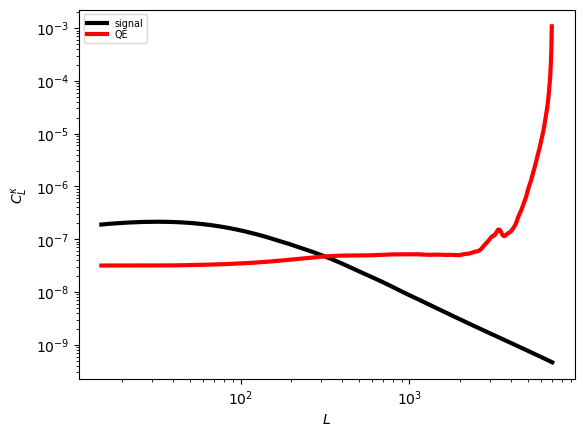

In [8]:
# print "Plot noise power spectra"

fig=plt.figure(0)
ax=fig.add_subplot(111)
#
ax.loglog(L, p2d_cmblens.fPinterp(L), 'k-', lw=3, label=r'signal')
#
Nq = fNqCmb_fft(L)
# Ns = fNsCmb_fft(L)
# Nd = fNdCmb_fft(L)
#Nsd = fNsdCmb_fft(L)
#NsB = fNsBCmb_fft(L)
#NssB = fNssBCmb_fft(L)
#
# ax.loglog(L, Ns, c=cS, label=r'shear')
# ax.loglog(L, Nd, c=cD, label=r'dilation')
ax.loglog(L, Nq, c=cQ, lw=3, label=r'QE')
#ax.loglog(L, NsB, c='y', label=r'shear B')a
#x.loglog(L, Nsd, c='c', ls='--', label=r'shear$\times$dilation')
#ax.loglog(L, 1./(1./Nd + 1./Ns), c=cQ, ls='-.', label=r'naive shear + dilation')
#ax.loglog(L, (Ns*Nd-Nsd**2)/(Ns+Nd-2.*Nsd), c=cQ, ls='--', lw=3, label=r'shear + dilation')
#ax.loglog(L, NssB, c='y', ls='-.', label=r'shear$\times$shear B')
#
ax.legend(loc=2, fontsize='x-small', labelspacing=0.1)
ax.set_xlabel(r'$L$')
ax.set_ylabel(r'$C_L^\kappa$')

plt.show()

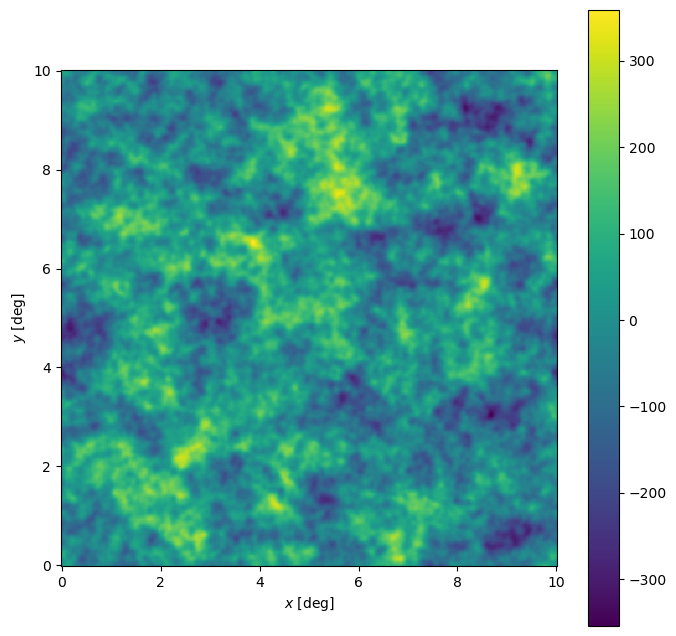

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


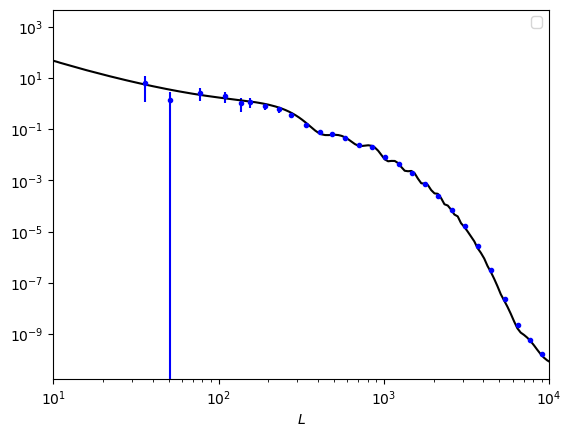

In [9]:
# print "Generate GRF unlensed CMB map (debeamed)"

cmb0Fourier = baseMap.genGRF(cmb.funlensedTT, test=False)
cmb0 = baseMap.inverseFourier(cmb0Fourier)
# print "plot unlensed CMB map"
baseMap.plot(cmb0)
# print "check the power spectrum"
lCen, Cl, sCl = baseMap.powerSpectrum(cmb0Fourier, theory=[cmb.funlensedTT], plot=True, save=False)

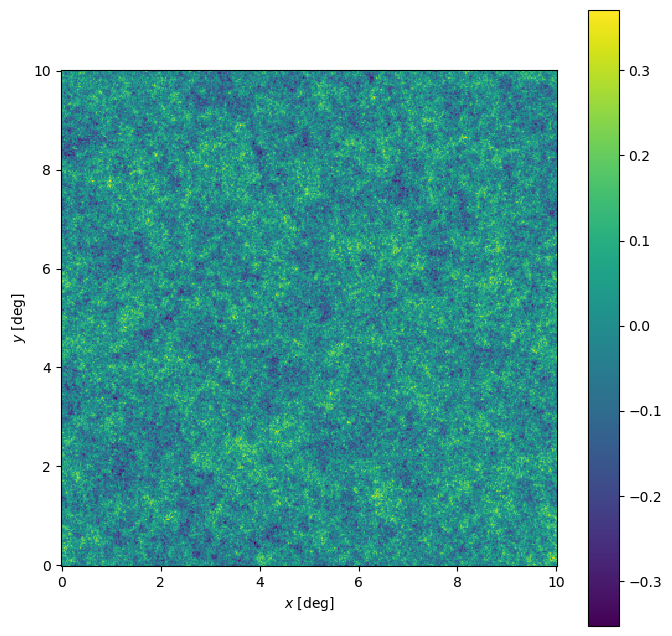

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


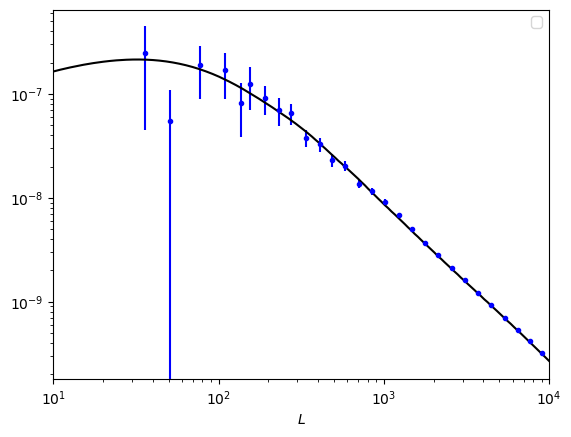

In [10]:
# print "Generate GRF kappa map"

kCmbFourier = baseMap.genGRF(p2d_cmblens.fPinterp, test=False)
kCmb = baseMap.inverseFourier(kCmbFourier)
# print "plot kappa map"
baseMap.plot(kCmb)
# print "check the power spectrum"
lCen, Cl, sCl = baseMap.powerSpectrum(kCmbFourier, theory=[p2d_cmblens.fPinterp], plot=True, save=False)

/Users/richardfeder/Documents/ciber/FlatSkyQE/basic_functions.py:108: RuntimeWarning: invalid value encountered in divide
  result[loc] = x[loc] / y[loc]


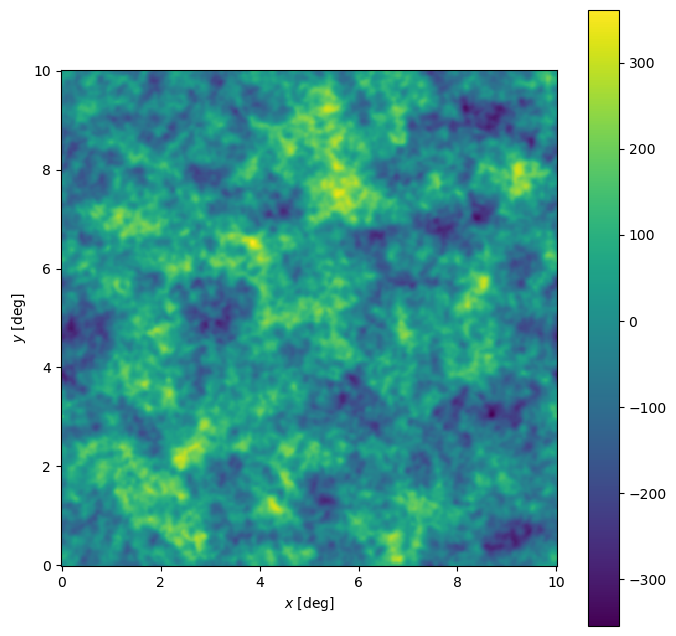

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


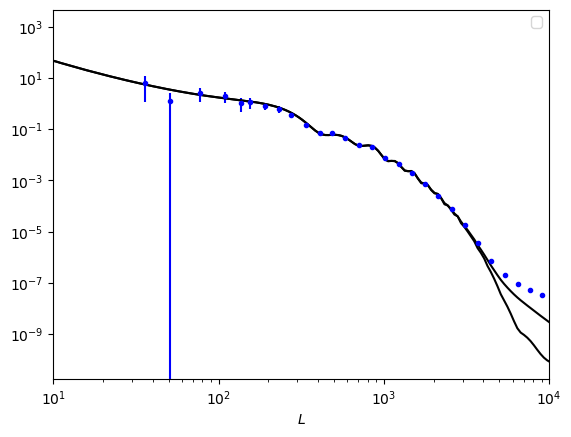

In [11]:
# print "Lens the CMB map"

lensedCmb = baseMap.doLensing(cmb0, kappaFourier=kCmbFourier)
lensedCmbFourier = baseMap.fourier(lensedCmb)
# print "plot lensed CMB map"
baseMap.plot(lensedCmb, save=False)
# print "check the power spectrum"
lCen, Cl, sCl = baseMap.powerSpectrum(lensedCmbFourier, theory=[cmb.funlensedTT, cmb.flensedTT], plot=True, save=False)

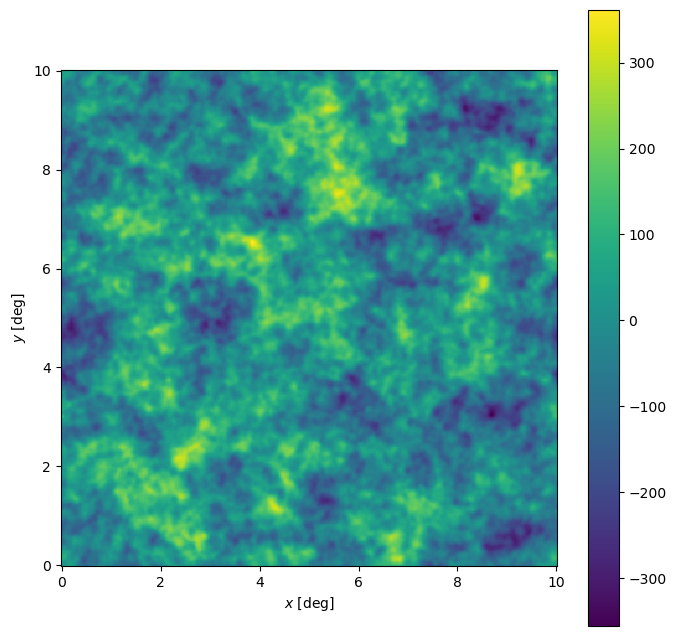

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


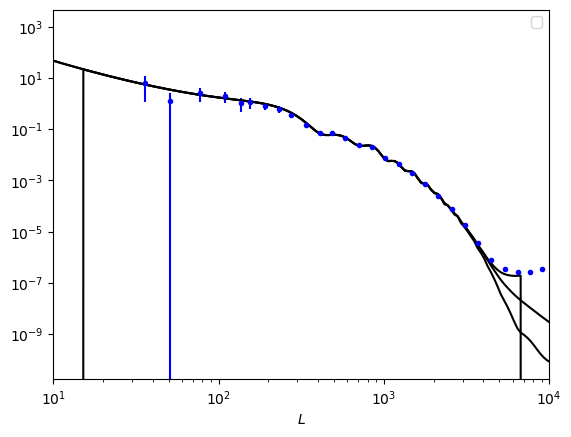

In [12]:
# print "Add white detector noise (debeamed)"

noiseFourier = baseMap.genGRF(cmb.fdetectorNoise, test=False)
totalCmbFourier = lensedCmbFourier + noiseFourier
totalCmb = baseMap.inverseFourier(totalCmbFourier)
baseMap.plot(totalCmb)
# print "check the power spectrum"
lCen, Cl, sCl = baseMap.powerSpectrum(totalCmbFourier,theory=[cmb.funlensedTT, cmb.flensedTT, cmb.fCtotal], plot=True, save=False)

lMin, lMax inputs to computeQuadEstKappaNorm: 30.0 3500.0
min max of WFDataFourier real is  -0.4312924908344976 0.4097194216720814
min max of WFDataFourier is  (-0.4312924908344976-0.32575305370594804j) (0.4097194216720814-0.07893214167900305j)
Doing full calculation: computeQuadEstPhiNormalizationFFT


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


saving Fourier map to./output/qCmb.txt
reading fourier map from./output/qCmb.txt


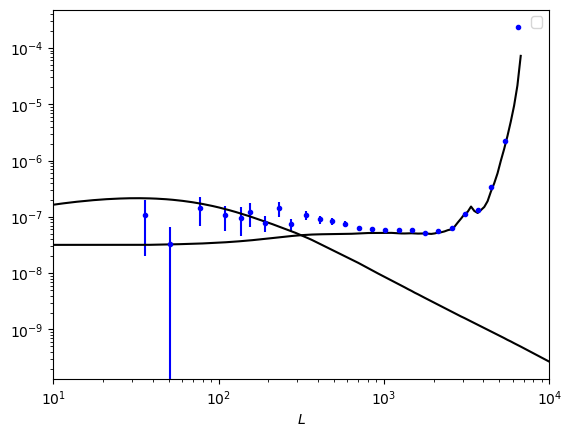

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


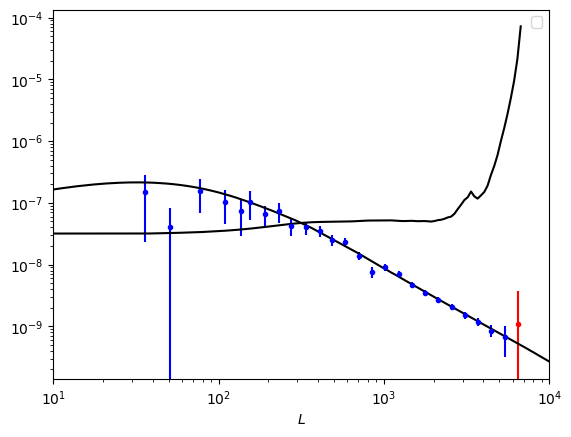

In [13]:
# print "Reconstructing kappa: standard quadratic estimator"

pathQCmb = "./output/qCmb.txt"
baseMap.computeQuadEstKappaNorm(cmb.funlensedTT, cmb.fCtotal, lMin=lMin, lMax=lMax, dataFourier=totalCmbFourier, test=False, path=pathQCmb)
qCmbFourier = baseMap.loadDataFourier(pathQCmb)

# print "Auto-power: kappa_rec"
lCen, Cl, sCl = baseMap.powerSpectrum(qCmbFourier,theory=[p2d_cmblens.fPinterp, fNqCmb_fft], plot=True, save=False)

# print "Cross-power: kappa_rec x kappa_true"
lCen, Cl, sCl = baseMap.crossPowerSpectrum(qCmbFourier, kCmbFourier, theory=[p2d_cmblens.fPinterp, fNqCmb_fft], plot=True, save=False)

In [13]:
print "Reconstructing kappa: shear estimator"

pathSCmb = "./output/sCmb.txt"
baseMap.computeQuadEstKappaShearNormCorr(cmb.funlensedTT, cmb.fCtotal, lMin=lMin, lMax=lMax, dataFourier=totalCmbFourier, test=False, path=pathSCmb)
sCmbFourier = baseMap.loadDataFourier(pathSCmb)

Reconstructing kappa: shear estimator


flat_map.py:2951: RuntimeWarning: divide by zero encountered in divide
  resultFourier *= -2. / self.l**2
flat_map.py:2951: RuntimeWarning: invalid value encountered in multiply
  resultFourier *= -2. / self.l**2


doing full calculation: computeQuadEstPhiShearNormalizationCorrectedFFT
saving Fourier map to ./output/sCmb.txt
reading fourier map from ./output/sCmb.txt


Auto-power: kappa_rec


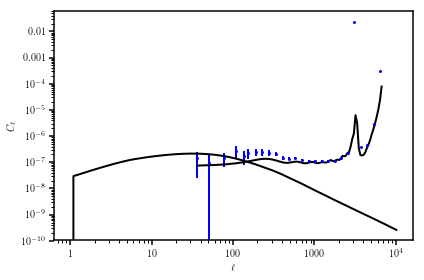

In [14]:
print "Auto-power: kappa_rec"
lCen, Cl, sCl = baseMap.powerSpectrum(sCmbFourier,theory=[p2d_cmblens.fPinterp, fNsCmb_fft], plot=True, save=False)

Cross-power: kappa_rec x kappa_true


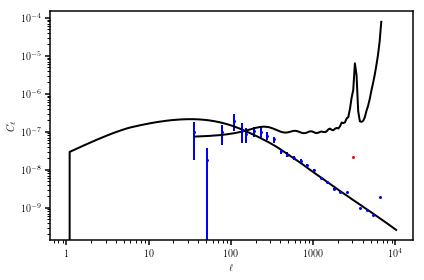

In [15]:
print "Cross-power: kappa_rec x kappa_true"
lCen, Cl, sCl = baseMap.crossPowerSpectrum(sCmbFourier, kCmbFourier, theory=[p2d_cmblens.fPinterp, fNsCmb_fft], plot=True, save=False)

In [16]:
print "Reconstructing kappa: magnification estimator"

pathDCmb = "./output/dCmb.txt"
baseMap.computeQuadEstKappaDilationNormCorr(cmb.funlensedTT, cmb.fCtotal, lMin=lMin, lMax=lMax, dataFourier=totalCmbFourier, test=False, path=pathDCmb)
dCmbFourier = baseMap.loadDataFourier(pathDCmb)

Reconstructing kappa: magnification estimator


flat_map.py:2405: RuntimeWarning: divide by zero encountered in divide
  productFourier *= - 2. / self.l**2
flat_map.py:2405: RuntimeWarning: invalid value encountered in multiply
  productFourier *= - 2. / self.l**2


doing full calculation: computeQuadEstPhiDilationNormalizationCorrectedFFT
saving Fourier map to ./output/dCmb.txt
reading fourier map from ./output/dCmb.txt


Auto-power: kappa_rec


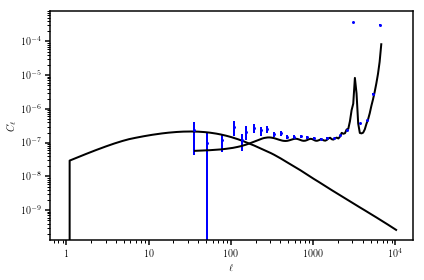

In [17]:
print "Auto-power: kappa_rec"
lCen, Cl, sCl = baseMap.powerSpectrum(dCmbFourier,theory=[p2d_cmblens.fPinterp, fNdCmb_fft], plot=True, save=False)

Cross-power: kappa_rec x kappa_true


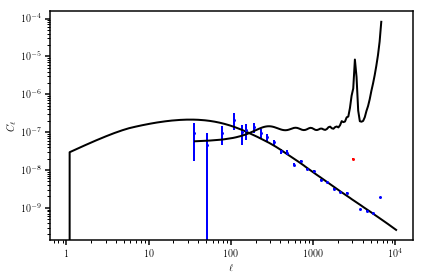

In [18]:
print "Cross-power: kappa_rec x kappa_true"
lCen, Cl, sCl = baseMap.crossPowerSpectrum(dCmbFourier, kCmbFourier, theory=[p2d_cmblens.fPinterp, fNdCmb_fft], plot=True, save=False)